<a href="https://colab.research.google.com/github/KarenKhou/SmartCloset/blob/main/MachineLearning/Colors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np

In [ ]:
def create_bar(height, width, color):
    bar = np.zeros((height, width, 3), np.uint8)
    bar[:] = color
    red, green, blue = int(color[2]), int(color[1]), int(color[0])
    return bar, (red, green, blue)

In [ ]:
img = cv2.imread('/content/IMAGES/Screenshot 2025-03-27 134914.png')
height, width, _ = np.shape(img)

In [ ]:
data = np.reshape(img, (height * width, 3))
data = np.float32(data)

In [ ]:
number_clusters = 5
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
flags = cv2.KMEANS_RANDOM_CENTERS
compactness, labels, centers = cv2.kmeans(data, number_clusters, None, criteria, 10, flags)

In [ ]:
font = cv2.FONT_HERSHEY_SIMPLEX
bars = []
rgb_values = []

for index, row in enumerate(centers):
    bar, rgb = create_bar(200, 200, row)
    bars.append(bar)
    rgb_values.append(rgb)

img_bar = np.hstack(bars)

for index, row in enumerate(rgb_values):
    image = cv2.putText(img_bar, f'{index + 1}. RGB: {row}', (5 + 200 * index, 200 - 10),
                        font, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    print(f'{index + 1}. RGB{row}')

1. RGB(149, 161, 177)
2. RGB(190, 206, 220)
3. RGB(242, 237, 239)
4. RGB(202, 216, 227)
5. RGB(121, 42, 52)


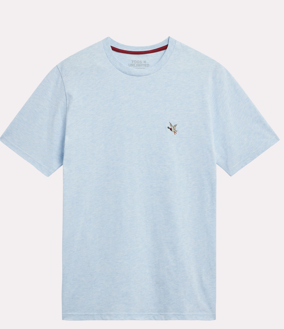

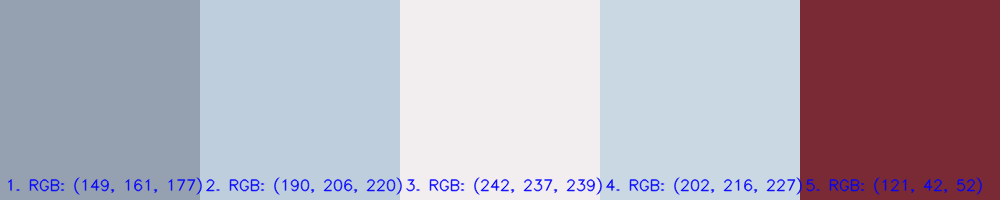

-1

In [ ]:
from google.colab.patches import cv2_imshow
cv2_imshow (img)
cv2_imshow( img_bar)
# cv2.imwrite('output/bar.jpg', img_bar)

cv2.waitKey(0)

Image: /content/IMAGES/Screenshot 2025-03-27 135236.png - Dominant Color: gray


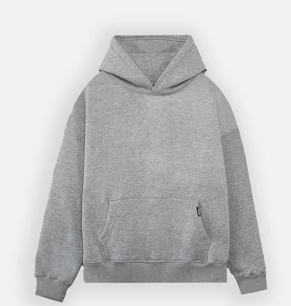

Image: /content/IMAGES/Screenshot 2025-03-27 135340.png - Dominant Color: indianred


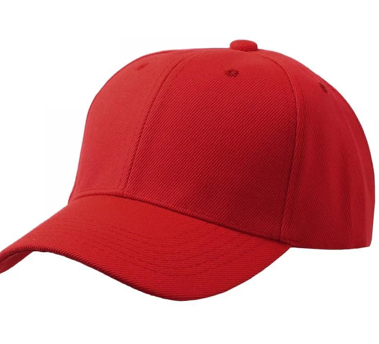

Image: /content/IMAGES/Screenshot 2025-03-27 135157.png - Dominant Color: darkolivegreen


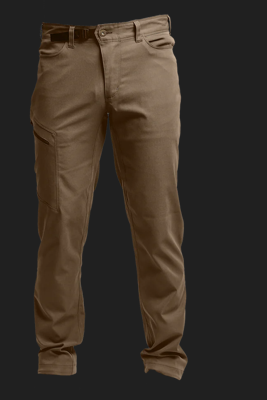

Image: /content/IMAGES/Screenshot 2025-03-27 134956.png - Dominant Color: maroon


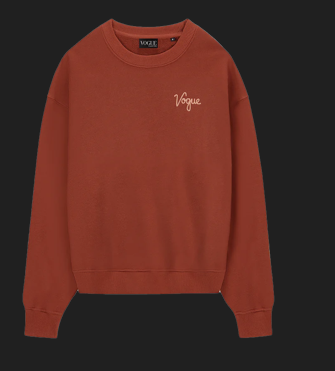

Image: /content/IMAGES/Screenshot 2025-03-27 135027.png - Dominant Color: darkslategray


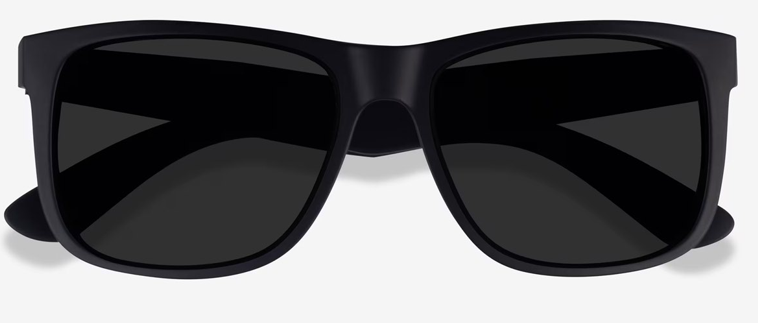

Image: /content/IMAGES/Screenshot 2025-03-27 135134.png - Dominant Color: slategray


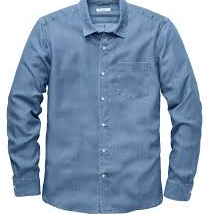

Image: /content/IMAGES/Screenshot 2025-03-27 135047.png - Dominant Color: sienna


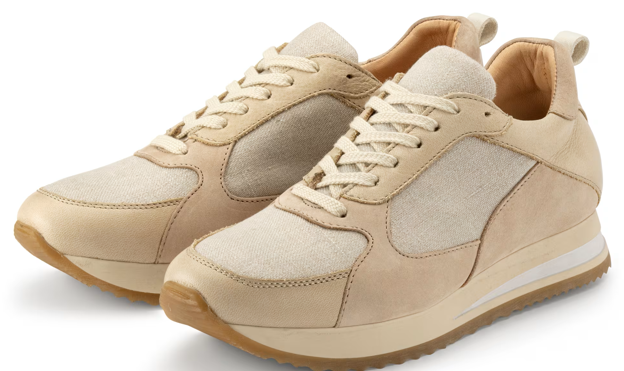

⚠️ Image /content/IMAGES/Screenshot 2025-03-27 135217.png might be dark blue! Checking...
Image: /content/IMAGES/Screenshot 2025-03-27 135217.png - Dominant Color: blue


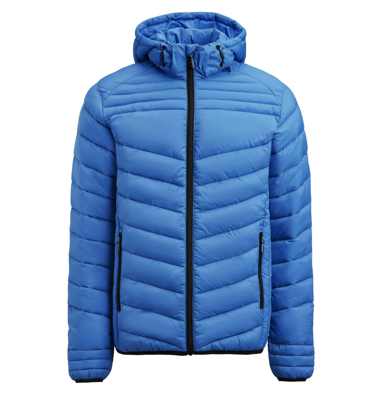

Image: /content/IMAGES/Screenshot 2025-03-27 134914.png - Dominant Color: lightsteelblue


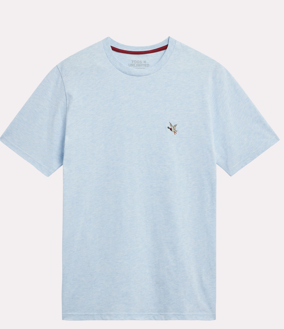

Image: /content/IMAGES/Screenshot 2025-03-27 135109.png - Dominant Color: darkslategray


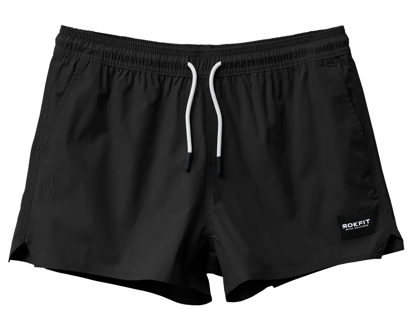

In [ ]:
!pip install webcolors==1.11
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import os
import webcolors

def closest_color(requested_color):
    """Find the closest known CSS3 color."""
    min_colors = {}
    for key, name in webcolors.CSS3_HEX_TO_NAMES.items():
        r_c, g_c, b_c = webcolors.hex_to_rgb(key)
        distance = (r_c - requested_color[0])**2 + (g_c - requested_color[1])**2 + (b_c - requested_color[2])**2
        min_colors[distance] = name
    return min_colors[min(min_colors.keys())]

def remove_background(image):
    """Removes the background using adaptive thresholding and morphological operations."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Adaptive thresholding to remove background more dynamically
    mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    # Morphological operations to remove small noise
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Apply mask to the image
    result = cv2.bitwise_and(image, image, mask=mask)

    return result

def process_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if img is None:
        print(f"Error loading image: {image_path}")
        return

    # Handle PNG transparency
    if img.shape[-1] == 4:  # PNG with Alpha Channel
        alpha_channel = img[:, :, 3]
        mask = alpha_channel > 128  # Keep only non-transparent areas
        img = img[:, :, :3]  # Remove alpha channel
    else:
        mask = np.ones(img.shape[:2], dtype=bool)

    # Remove background
    img_no_bg = remove_background(img)

    # Reshape pixels for clustering
    pixels = img_no_bg.reshape((-1, 3))

    # **Ignore pure black pixels** (R,G,B < 30)
    pixels = np.array([p for p in pixels if np.any(p > 30)], dtype=np.float32)

    # **Extra check: If the image is still mostly black, assume original image is dominant**
    if len(pixels) == 0:
        print(f"Image: {image_path} - Keeping original colors (avoiding black misclassification)")
        pixels = img.reshape((-1, 3)).astype(np.float32)

    # Apply KMeans clustering
    number_clusters = 5
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    flags = cv2.KMEANS_RANDOM_CENTERS
    _, labels, centers = cv2.kmeans(pixels, number_clusters, None, criteria, 10, flags)

    # Find the most dominant color
    unique, counts = np.unique(labels, return_counts=True)
    dominant_index = unique[np.argmax(counts)]
    dominant_color = centers[dominant_index]

    # Convert to color name
    dominant_color_name = closest_color((int(dominant_color[2]), int(dominant_color[1]), int(dominant_color[0])))

    # **Check if the detected color is "black" but might be dark blue**
    if dominant_color_name == "black":
        print(f"⚠️ Image {image_path} might be dark blue! Checking...")

        # If blue is strong (B > R and B > G), override it to "blue"
        if dominant_color[0] > dominant_color[1] and dominant_color[0] > dominant_color[2]:
            dominant_color_name = "blue"

    print(f"Image: {image_path} - Dominant Color: {dominant_color_name}")

    # Show only the original image
    cv2_imshow(img)

def process_folder(folder_path):
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('png', 'jpg', 'jpeg')):
            image_path = os.path.join(folder_path, filename)
            process_image(image_path)

# Change 'input_folder' to your folder containing images
input_folder = '/content/IMAGES'
process_folder(input_folder)
